# 4 Ejercicios

Santiago Andrés Acosta Díaz

Primero, corremos lo que se necesita sí o sí correr para tener la info que necesitamos

In [1]:
import matplotlib 
#matplotlib.use('Agg')

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline 

# Python standard-libraries to download data from the web
from urllib.parse import urlencode
from urllib.request import urlretrieve

#Some astropy submodules that you know already
from astropy import units as u
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy.io import fits

#only here to display images
from IPython.display import Image

# These are the new modules for this notebook
from astroquery.simbad import Simbad
from astroquery.sdss import SDSS

import requests
import PIL 
#from PIL import Image


galaxy_name = 'NGC5406'

# Information from the name of the galaxy in the SkyCoord server
galaxy = SkyCoord.from_name(galaxy_name)

# Get the coordinates of the galaxy
pos = coords.SkyCoord(galaxy.ra, galaxy.dec, frame='icrs')

#### Exercise 1

Identify at least three of the lines seen in the spectrum of NGC5406. Using that information, what is the redshift of this galaxy?


Para responder ese ejercicio, nos robamos el código del profe que grafica el espectro de emisión medido y las líneas espectrales teóricas

[O_II] 3727  -> [3729.87544376]
[O_III] 5007  -> [5008.23966962]
H_alpha  -> [6564.61397371]


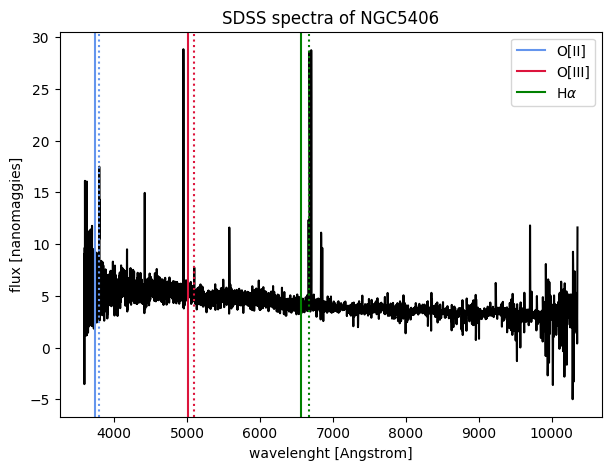

In [2]:
xid = SDSS.query_region(pos, spectro=True,radius=2.5*u.arcmin)
spectra = SDSS.get_spectra(matches=xid)
spectra_data = spectra[0][1].data
lines = spectra[0][3].data

for n in ['[O_II] 3727', '[O_III] 5007', 'H_alpha']:
    print(n, " ->", lines['LINEWAVE'][lines['LINENAME']==n])
    
plt.figure(figsize=(7,5))
plt.plot(10**spectra_data['loglam'], spectra_data['flux'], color='black')
plt.axvline(x=lines['LINEWAVE'][lines['LINENAME']=='[O_II] 3727'], label=r'O[II]', color='cornflowerblue')
plt.axvline(x=lines['LINEWAVE'][lines['LINENAME']=='[O_III] 5007'], label=r'O[III]', color='crimson')
plt.axvline(x=lines['LINEWAVE'][lines['LINENAME']=='H_alpha'], label=r'H$\alpha$', color='green')

plt.axvline(x=3790, color='cornflowerblue', linestyle='dotted')
plt.axvline(x=5090, color='crimson', linestyle='dotted')
plt.axvline(x=6670, color='green', linestyle='dotted')

plt.xlabel('wavelenght [Angstrom]')
plt.ylabel('flux [nanomaggies]')
plt.title('SDSS spectra of '+galaxy_name)
plt.legend()
plt.show()

En este caso, tenemos 3 líneas teóricas (marcadas en colores) las cuales corresponden con el $\lambda$ del espectro de emisión real de ciertos elementos (de los que sospechamos que está hecha la galaxia). 

Como estamos viendo si este espectro presenta _redshift_, lo que nos interesa es ver estas líneas qué tanto se mueven hacia la derecha ($\lambda$s mayores, más rojos). En este caso, grafiqué (a ojo) la posición de estos redshifts, y la fórmula para obtener el $z$ de cada línea de emisión es

$$
    z = \frac{\lambda_{obs} - \lambda_{teo}}{\lambda_{obs}}
$$

con lo que tenemos

In [3]:
lambda_teo_1 = lines['LINEWAVE'][lines['LINENAME']=='[O_II] 3727']
lambda_teo_2 = lines['LINEWAVE'][lines['LINENAME']=='[O_III] 5007']
lambda_teo_3 = lines['LINEWAVE'][lines['LINENAME']=='H_alpha']

lambda_obs_1 = 3790
lambda_obs_2 = 5090
lambda_obs_3 = 6670

def z(teo, obs):
    return ((obs - teo) / obs)


print(f"z para la primera línea: {z(lambda_teo_1, lambda_obs_1)}")
print(f"z para la primera línea: {z(lambda_teo_2, lambda_obs_2)}")
print(f"z para la primera línea: {z(lambda_teo_3, lambda_obs_3)}")

z para la primera línea: [0.015864]
z para la primera línea: [0.01606293]
z para la primera línea: [0.0158]


con lo que podemos decir que el redshift de la galaxia es de

$$
    z \approx 0.0159
$$


#### Exercise 2

Download the FITS images in the filters u,g,r,z,i for NGC5406. Plot in five different panels the logarithm of the flux in each of the bands (always cropping around the galaxy). Why do the images look different?



Nuevamente, nos robamos el código del profe para crear las imágenes

In [4]:
# Creamos una función que nos prepara la imagen para cada banda
def get_im_band(_band, clip = True):
    # Get the photometric inoformation in the g-band
    images = SDSS.get_images(matches=xid, band=_band)
    image_data =  images[0][0].data - np.min(images[0][0].data) # Dejamos los vals negativos en el suelo
    clipped_image = image_data.copy()

    if clip:
        clipped_image[clipped_image>1.0]=1.0
        cropped_image = np.log10(clipped_image[125:475,750:1100])   # Aquí hacemos el crop y log directo 
        
        return cropped_image
    else:
        clipped_image[clipped_image>1.0]=1.0
        return np.log10(clipped_image)

# Creamos todas las imágenes
i_img = get_im_band('i')
print("i donwloaded")
r_img = get_im_band('r')
print("r donwloaded")
g_img = get_im_band('g')
print("g donwloaded")
z_img = get_im_band('z')
print("z donwloaded")
u_img = get_im_band('u')
print("i donwloaded")

images = [i_img, r_img, g_img, z_img, u_img]
names = ["i band", "r band", "g band", "z band", "u band"]


i donwloaded
r donwloaded
g donwloaded
z donwloaded
i donwloaded


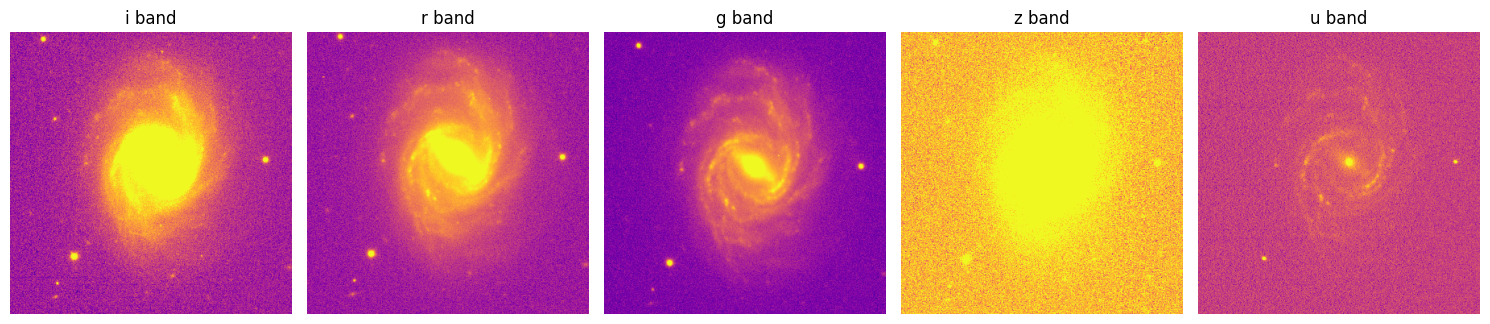

In [5]:
# Ploteamos en los 5 páneles
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for (i, ax), name in zip(enumerate(axes), names):
    ax.imshow(images[i], cmap = "plasma")
    ax.set_title(name)
    
    ax.axis('off')  # Hides the x/y ticks for a cleaner look

plt.tight_layout()
plt.show()

Las imágenes se ven diferentes porque son diferentes bandas del espectro eletromagnético, y las intensidades de cada una dependen bastante de la compocisión de la galaxia y su redshift. Similar a si intentamos graficar el canal azul en una imagen completamente roja, no obtendremos nada.

#### Exercise 3

Compute the radial flux profile of NGC5406. To do that take 10 different lines starting from the center of the galaxy and plot the flux as a function of radius for those ten lines. What kind of function should fit your results?



Para hacer esto, vamos a crear una función que tome la imagen, que en este caso __tomaremos la banda _g___ por ser la más bonita, y va a trazar una línea radial en esa imagen centrada en un punto `p` (el centro, a ojo, de la galaxia). También, para evitar ruido, la línea va a tener un grosor dado, y el perfil que se va a graficar es el promedio en el grosor de esta línea. Por último, para normalizar, cada linea (que tendrá su dirección en $\theta$) tendrá una longitud tal que sólo se analice la galaxia, es decir, en los ángulos más estrechos, la linea será más corta, y lo contrario para los lados más largos.

Para hacer esto, le pedí a _QWen_ que lo haga.

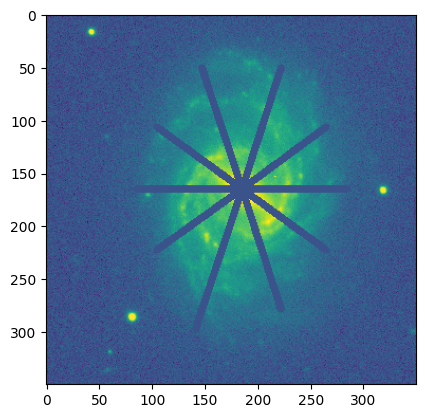

In [6]:
import cv2   # Esto facilita trazar la línea esta

# Esta es para dibujar
def draw_radial_line(mod, p, length, thickness, theta, intensity=0.0):
    """
    Draws a radial line on a 2D numpy image using OpenCV.
    """
    x0, y0 = p
    x1 = x0 + length * np.cos(theta)
    y1 = y0 + length * np.sin(theta)
    
    # cv2.line modifies the array in-place. 
    # Note: cv2 expects coordinates as (x, y) which is (col, row).
    cv2.line(
        mod, 
        (int(x0), int(y0)), 
        (int(x1), int(y1)), 
        color=intensity, 
        thickness=int(thickness),
    )
    
    return mod


# Esta es para extraer el perdil
def extract_line_profile(img, p, length, thickness, theta):
    """
    Extracts the intensity profile along a radial line using OpenCV's 
    rotation and slicing capabilities.
    """
    x0, y0 = p
    h, w = img.shape[:2]
    
    # 1. Prepare the image and a "validity mask" (to handle image borders)
    # We use float32 to safely calculate averages without integer overflow
    img_float = img.astype(np.float32)
    mask = np.ones((h, w), dtype=np.float32)
    
    # 2. Calculate rotation matrix to make the line perfectly horizontal
    # We rotate around point p by -theta
    angle_deg = -np.degrees(theta)
    M = cv2.getRotationMatrix2D((x0, y0), angle_deg, 1.0)
    
    # 3. Warp both the image and the mask
    # IMPORTANT: We use INTER_NEAREST to prevent blurring/interpolation. 
    # This ensures we are averaging the exact original pixel values.
    warped_img = cv2.warpAffine(img_float, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)
    warped_mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)
    
    # 4. Define the bounding box for the horizontal strip
    # Because of the math, the rotated line ALWAYS starts at (x0, y0) and goes exactly to the right
    length_int = int(np.round(length))
    thickness_int = int(np.round(thickness))
    
    x_start = int(np.round(x0))
    x_end = x_start + length_int
    
    y_start = int(np.round(y0 - thickness_int / 2))
    y_end = y_start + thickness_int
    
    # Clip coordinates to ensure we don't index outside the image boundaries
    x_start_c = max(0, x_start)
    x_end_c = min(w, x_end)
    y_start_c = max(0, y_start)
    y_end_c = min(h, y_end)
    
    if x_start_c >= x_end_c or y_start_c >= y_end_c:
        return np.array([]) # Line is completely outside the image
        
    # 5. Extract the horizontal strip
    strip_img = warped_img[y_start_c:y_end_c, x_start_c:x_end_c]
    strip_mask = warped_mask[y_start_c:y_end_c, x_start_c:x_end_c]
    
    # 6. Average along the y-axis (axis=0) for each column
    # We multiply by the mask to ignore pixels that fell outside the original image bounds
    sum_img = np.sum(strip_img * strip_mask, axis=0)
    sum_mask = np.sum(strip_mask, axis=0)
    
    # Calculate the mean, avoiding division by zero
    profile = np.divide(sum_img, sum_mask, out=np.zeros_like(sum_img), where=sum_mask!=0)
    
    return profile
    

# Aquí obtenso todos estos valores
thetas = [0.0 + (2.*np.pi / 10.0)*i for i in range(10)]
lengths = [100, 100, 120, 140, 100, 100, 100, 120, 120, 100]

test = g_img.copy()
profiles = list()

for t, l in zip(thetas, lengths): 
    test = draw_radial_line(test, (185, 165), l, 5, t, intensity = -1.0)
    profile = extract_line_profile(g_img, (185, 165), l, 5, t)
    plt.imshow(test)
    profiles.append(profile)
    
plt.show()

Las anteriores son las líneas a analizar. Ahora, miremos los perfiles

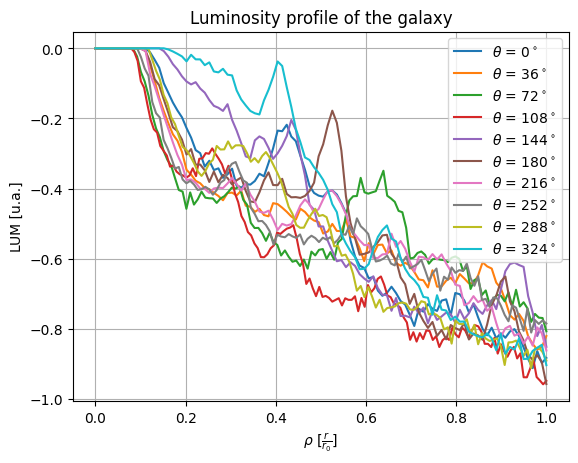

In [7]:
for p, t in zip(profiles, thetas):
    x = np.linspace(0.0, 1.0, len(p))   # Normalizamos el eje y 
    plt.plot(x, p, label = rf"$\theta$ = {(t / np.pi * 180.):.0f}$^\circ$")

plt.title("Luminosity profile of the galaxy")
plt.grid()
plt.legend()
plt.xlabel(r"$\rho$ [$\frac{r}{r_0}$]")
plt.ylabel(r"LUM [u.a.]")
plt.show()


En general, vemos que los perfiles decaen casi que linealmente y casi que a la misma taza, cosa que, si no estoy mal (no soy de astrofísica, esto es especulación) debería ocurrir.

Lo anterior lo pienso pues una vez hicimos el ejercicio de la luminosidad en una galaxia, la cual sólo era función del radio y no de $\theta$, por lo que creería que esto está bien al no parecer haber ningún comportamiento especial respecto a los $\theta$ graficados.

Ahora, estos perfiles fueron tomados de la imagen del __logaritmo__ del flujo, y parecen tener una pendiente diferente de 1, por lo que se podría decir que este flujo disminuye con el inverso de alguna potencia del radio.

Vemos que en los perfiles hay algunos saltos, que corresponden a los brazos (que son luminosos) en la galaxia.

#### Exercise 4

Repeat the same producedure of this notebook (including the exercises 2 and 3) for the galaxy `SDSS J013755.71+010004.9`.

Why does this galaxy look so different from NGC5406?


In [28]:
# AQUÍ CAMBIAMOS EL NOMBRE
galaxy_name = 'SDSS J013755.71+010004.9'

# DE AQUÍ EN ADELANTE ES COPIA Y PEGA
galaxy = SkyCoord.from_name(galaxy_name)
pos = coords.SkyCoord(galaxy.ra, galaxy.dec, frame='icrs')
xid = SDSS.query_region(pos, spectro=True,radius=2.5*u.arcmin)

__PARA EL SEGUNDO EJERCICIO__

In [29]:
# Creamos todas las imágenes
i_img = get_im_band('i', clip = False)
print("i donwloaded")
r_img = get_im_band('r', clip = False)
print("r donwloaded")
g_img = get_im_band('g', clip = False)
print("g donwloaded")
z_img = get_im_band('z', clip = False)
print("z donwloaded")
u_img = get_im_band('u', clip = False)
print("i donwloaded")


/tmp/ipykernel_5079/786285585.py:15: RuntimeWarning: divide by zero encountered in log10
  return np.log10(clipped_image)


i donwloaded
r donwloaded
g donwloaded
z donwloaded
i donwloaded


In [30]:
images = [i_img, r_img, g_img, z_img, u_img]
names = ["i band", "r band", "g band", "z band", "u band"]

In [55]:
x0, x1, y0, y1 = 700, 900, 1450, 1650
images = [i_img[x0:x1, y0:y1], r_img[x0:x1, y0:y1], g_img[x0:x1, y0:y1], z_img[x0:x1, y0:y1], u_img[x0:x1, y0:y1]]
names = ["i band", "r band", "g band", "z band", "u band"]

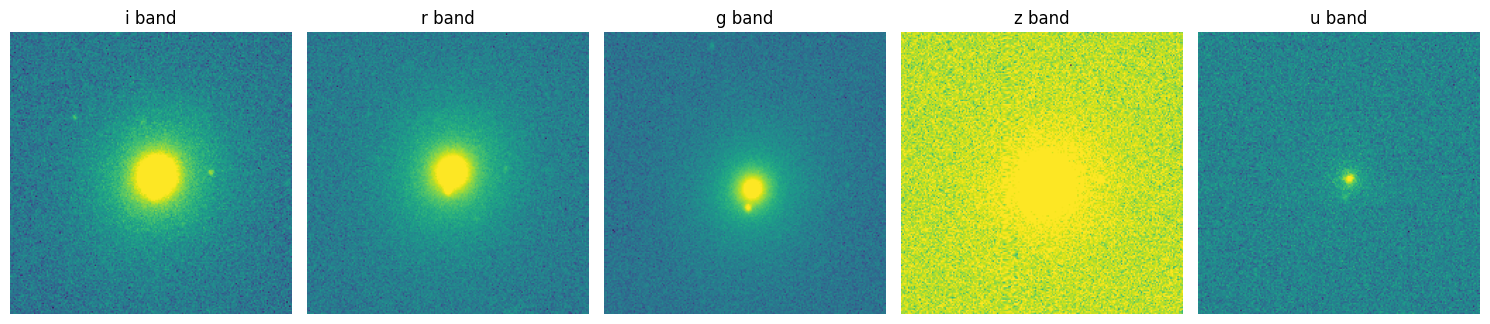

In [56]:
# Ploteamos en los 5 páneles
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for (i, ax), name in zip(enumerate(axes), names):
    ax.imshow(images[i], cmap = "viridis")
    ax.set_title(name)
    
    ax.axis('off')  # Hides the x/y ticks for a cleaner look

plt.tight_layout()
plt.show()

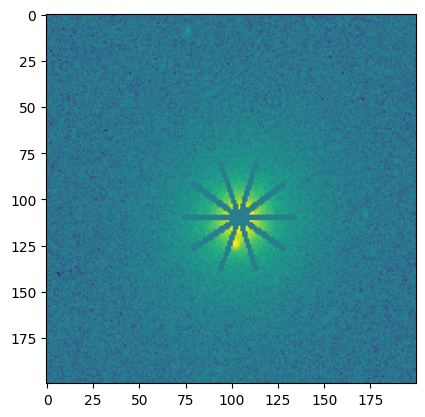

In [64]:
# Aquí obtenso todos estos valores
thetas = [0.0 + (2.*np.pi / 10.0)*i for i in range(10)]
lengths = [30 for i in range(10)]

test = g_img[x0:x1,y0:y1].copy()
profiles = list()

p = (104, 110)

for t, l in zip(thetas, lengths): 
    test = draw_radial_line(test, p, l, 2, t, intensity = -1.0)
    profile = extract_line_profile(g_img[x0:x1,y0:y1], p, l, 5, t)
    plt.imshow(test)
    profiles.append(profile)
    
plt.show()

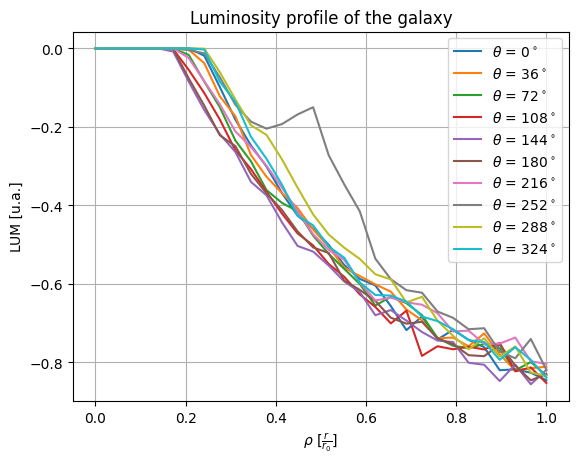

In [65]:
for p, t in zip(profiles, thetas):
    x = np.linspace(0.0, 1.0, len(p))   # Normalizamos el eje y 
    plt.plot(x, p, label = rf"$\theta$ = {(t / np.pi * 180.):.0f}$^\circ$")

plt.title("Luminosity profile of the galaxy")
plt.grid()
plt.legend()
plt.xlabel(r"$\rho$ [$\frac{r}{r_0}$]")
plt.ylabel(r"LUM [u.a.]")
plt.show()


En general, suponiendo que filtré correctamente la galaxia que era (que no creo, hay muchas [ya lo corregí hahaha]), lo que podría decir es que la diferencia principal en todo, especialmente el perfil de luminosidad, es el tipo de galaxia que estamos tratando: en este caso, sería una galaxia circular sin brazos, sin estructura, por lo que es prácticamente homogenea su distribución de densidad y va a caer con la más de las típicas leyes de decaimiento exponencial. 


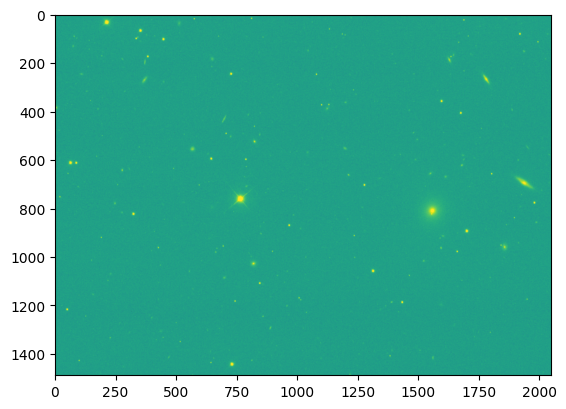

In [67]:
plt.imshow(g_img)
plt.show()